# Task 2 - BM25 Ranking and Search Results Evaluation

---

In [1]:
# !pip install rank-bm25 ir-measures --q

In [2]:
import os
import re
import time
import pickle
from pathlib import Path
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi
import ir_measures
from ir_measures import P, AP, nDCG
from tqdm.notebook import tqdm

for pkg in ['punkt', 'punkt_tab', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

DATA_DIR = Path('../datasets/wikIR1k')
RUNS_DIR = Path('runs')
MODELS_DIR = Path('models')
RUNS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 52
TOP_K = 100
VARIANTS = ['original', 'stemmed', 'lemmatized']

In [3]:
DOCS_PATH = os.path.join(DATA_DIR, 'documents.csv')
SPLITS = {}
for split in ['training', 'validation', 'test']:
    sdir = DATA_DIR / split
    SPLITS[split] = {
        'queries': os.path.join(Path(sdir), 'queries.csv'),
        'qrels': os.path.join(Path(sdir), 'qrels')
    }

In [4]:
SPLITS

{'training': {'queries': '../datasets/wikIR1k/training/queries.csv',
  'qrels': '../datasets/wikIR1k/training/qrels'},
 'validation': {'queries': '../datasets/wikIR1k/validation/queries.csv',
  'qrels': '../datasets/wikIR1k/validation/qrels'},
 'test': {'queries': '../datasets/wikIR1k/test/queries.csv',
  'qrels': '../datasets/wikIR1k/test/qrels'}}

In [5]:
def load_documents(path):
    df = pd.read_csv(path, index_col='id_right')
    df.index = df.index.astype(str)
    return df['text_right'].fillna('').to_dict()

def load_queries(path):
    df = pd.read_csv(path, index_col='id_left')
    df.index = df.index.astype(str)
    return df['text_left'].fillna('').to_dict()

def load_qrels(path):
    qrels = {}
    with open(path) as f:
        for line in f:
            parts = line.split()
            if len(parts) < 3:
                continue
            if len(parts) >= 4:
                qid, docid, rel = parts[0], parts[2], parts[3]
            else:
                qid, docid, rel = parts[0], parts[1], parts[2]
            try:
                rel = int(rel)
            except ValueError:
                continue
            qrels.setdefault(str(qid), {})[str(docid)] = rel
    return qrels

---


## Task 1. Provide basic statistics for the test queries

In [6]:
documents = load_documents(DOCS_PATH)
test_queries = load_queries(SPLITS['test']['queries'])
test_qrels = load_qrels(SPLITS['test']['qrels'])

pd.Series({
    'documents': len(documents),
    'test queries': len(test_queries),
    'test qrels': len(test_qrels),
}, name='count')

documents       369721
test queries       100
test qrels         100
Name: count, dtype: int64

In [7]:
q_lengths = np.array([len(q.split()) for q in test_queries.values()])
rel_counts = np.array([len(test_qrels.get(qid, {})) for qid in test_queries])
doc_lengths = np.array([len(d.split()) for d in documents.values()])

basic_stats = pd.DataFrame({'value': {
    'документов': len(documents),
    'Test queries': len(test_queries),
    'Среднее число слов в документах': round(float(doc_lengths.mean()), 2),
    'Query length min': int(q_lengths.min()),
    'Query length max': int(q_lengths.max()),
    'Query length mean': round(float(q_lengths.mean()), 2),
    'Query length median': float(np.median(q_lengths)),
    'Relevant docs/query min': int(rel_counts.min()),
    'Relevant docs/query max': int(rel_counts.max()),
    'Relevant docs/query mean': round(float(rel_counts.mean()), 2),
    'Relevant docs/query median': float(np.median(rel_counts)),
}})

basic_stats

,value
документов,369721.00
Test queries,100.00
Среднее число слов в документах,197.70
Query length min,1.00
Query length max,9.00
Query length mean,2.07
Query length median,2.00
Relevant docs/query min,6.00
Relevant docs/query max,2759.00
Relevant docs/query mean,44.35


In [8]:
list(test_queries.keys())[np.argmax(rel_counts)], list(test_queries.values())[np.argmax(rel_counts)]

('13540', 'united kingdom')

In [11]:
len(test_qrels[list(test_queries.keys())[np.argmax(rel_counts)]])

2759

In [12]:
q_edit = np.array([len(q.split()) for q in test_queries.values() if q != 'united kingdom'])
rel_edit = np.array([len(test_qrels.get(k, {})) for k, v in test_queries.items() if v != 'united kingdom'])

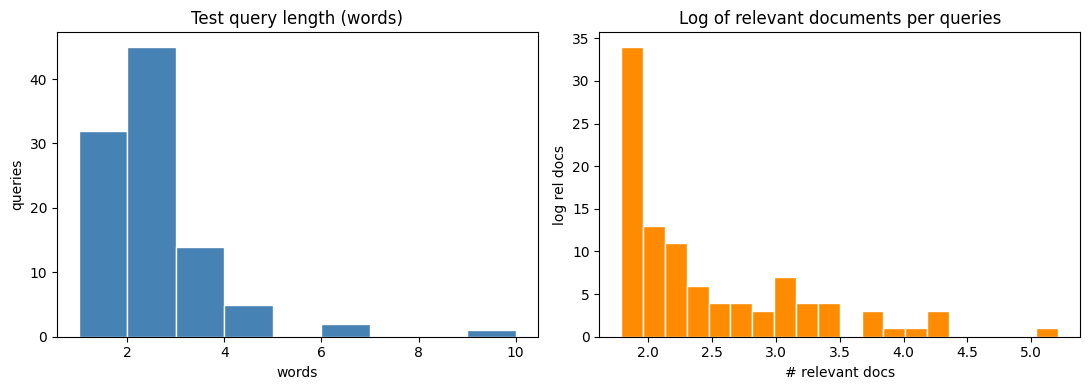

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(q_edit, bins=range(int(q_edit.min()), int(q_edit.max()) + 2),
           color='steelblue', edgecolor='white')
ax[0].set_title('Test query length (words)')
ax[0].set_xlabel('words')
ax[0].set_ylabel('queries')
ax[1].hist(np.log(rel_edit), bins=20, color='darkorange', edgecolor='white')
ax[1].set_title('Log of relevant documents per queries')
ax[1].set_xlabel('# relevant docs')
ax[1].set_ylabel('log rel docs')
plt.tight_layout()
plt.show()

---

## Preprocessing

### Tokenizer and normalizers

In [14]:
TOKEN_RE = re.compile(r'[a-z0-9]+')
_stemmer = PorterStemmer()
_lemmatizer = WordNetLemmatizer()


def tokenize(text):
    return TOKEN_RE.findall(text.lower())


@lru_cache(maxsize=None)
def stem(word):
    return _stemmer.stem(word)


@lru_cache(maxsize=None)
def lemma(word):
    return _lemmatizer.lemmatize(word)


def preprocess(text, variant):
    toks = tokenize(text)
    if variant == 'stemmed':
        return [stem(t) for t in toks]
    if variant == 'lemmatized':
        return [lemma(t) for t in toks]
    return toks

### Переделываем корпус

In [15]:
CORPUS_CACHE = MODELS_DIR / 'corpus_variants.pkl'

if CORPUS_CACHE.exists():
    with open(CORPUS_CACHE, 'rb') as f:
        _cache = pickle.load(f)
    doc_ids = _cache['doc_ids']
    corpus_tok = _cache['corpus_tok']
else:
    doc_ids = list(documents)
    corpus_tok = {}
    for variant in VARIANTS:
        corpus_tok[variant] = [preprocess(documents[d], variant) for d in tqdm(doc_ids, desc='')]
    with open(CORPUS_CACHE, 'wb') as f:
        pickle.dump({'doc_ids': doc_ids, 'corpus_tok': corpus_tok}, f)

In [16]:
# with open(CORPUS_CACHE, 'rb') as f:
#     _cache = pickle.load(f)
# doc_ids = _cache['doc_ids']
# corpus_tok = _cache['corpus_tok']
# pd.Series({v: len(corpus_tok[v]) for v in VARIANTS}, name='documents')

### Перестраиваем запросы

In [17]:
query_tok = {
    v: {qid: preprocess(test_queries[qid], v) for qid in test_queries}
    for v in VARIANTS
}

---

## Task 2. Run test queries on three collection variants 
using tf.idf and Rank-BM25: original, stemmed, lemmatized (don’t forget to process queries accordingly). Estimate the query execution time. Store the results in the TREC runs format. (20)

In [18]:
def top_k_indices(scores, k):
    k = min(k, len(scores))
    if k >= len(scores):
        return np.argsort(-scores)
    part = np.argpartition(-scores, k - 1)[:k]
    return part[np.argsort(-scores[part])]


def build_tfidf(corpus_variant):
    vectorizer = TfidfVectorizer(token_pattern=r'\S+', lowercase=False)
    matrix = vectorizer.fit_transform(' '.join(toks) for toks in corpus_variant)
    return vectorizer, matrix


def retrieve_tfidf(vectorizer, matrix, query_tokens, k=TOP_K):
    q = vectorizer.transform([' '.join(query_tokens)])
    sims = cosine_similarity(q, matrix).ravel()
    idx = top_k_indices(sims, k)
    return [(doc_ids[i], float(sims[i])) for i in idx]


def retrieve_bm25(model, query_tokens, k=TOP_K):
    scores = model.get_scores(query_tokens)
    idx = top_k_indices(scores, k)
    return [(doc_ids[i], float(scores[i])) for i in idx]


def write_trec_run(ranking_by_query, run_name, path):
    with open(path, 'w') as f:
        for qid, ranked in ranking_by_query.items():
            for rank, (docid, score) in enumerate(ranked, 1):
                f.write(f'{qid} Q0 {docid} {rank} {score:.6f} {run_name}\n')

In [ ]:
runs = {}
timings = []
models = {'tfidf': {}, 'bm25': {}}

for variant in VARIANTS:
    vectorizer, matrix = build_tfidf(corpus_tok[variant])
    models['tfidf'][variant] = (vectorizer, matrix)
    bm25 = BM25Okapi(corpus_tok[variant])
    models['bm25'][variant] = bm25

    t0 = time.perf_counter()
    tfidf_ranking = {qid: retrieve_tfidf(vectorizer, matrix, query_tok[variant][qid])
                     for qid in tqdm(test_queries, desc='')}
    t_tfidf = time.perf_counter() - t0

    t0 = time.perf_counter()
    bm25_ranking = {qid: retrieve_bm25(bm25, query_tok[variant][qid])
                    for qid in tqdm(test_queries, desc='')}
    t_bm25 = time.perf_counter() - t0

    runs[f'tfidf_{variant}'] = tfidf_ranking
    runs[f'bm25_{variant}'] = bm25_ranking
    write_trec_run(tfidf_ranking, f'tfidf_{variant}', RUNS_DIR / f'tfidf_{variant}.txt')
    write_trec_run(bm25_ranking, f'bm25_{variant}', RUNS_DIR / f'bm25_{variant}.txt')
    timings.append({'model': 'tfidf', 'variant': variant, 'seconds': round(t_tfidf, 3)})
    timings.append({'model': 'bm25', 'variant': variant, 'seconds': round(t_bm25, 3)})

pd.DataFrame(timings)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

,model,variant,seconds
0,tfidf,original,70.052
1,bm25,original,26.246
2,tfidf,stemmed,65.574
3,bm25,stemmed,25.200
4,tfidf,lemmatized,68.055
5,bm25,lemmatized,25.221


### Back up

In [ ]:
# for variant in VARIANTS:
#     with open(MODELS_DIR / f'bm25_{variant}.pkl', 'wb') as f:
#         pickle.dump(models['bm25'][variant], f)
#     with open(MODELS_DIR / f'tfidf_{variant}.pkl', 'wb') as f:
#         pickle.dump(models['tfidf'][variant], f)

### Reload from dump

In [ ]:
# loaded_models = {'tfidf': {}, 'bm25': {}}
# for variant in VARIANTS:
#     with open(MODELS_DIR / f'bm25_{variant}.pkl', 'rb') as f:
#         loaded_models['bm25'][variant] = pickle.load(f)
#     with open(MODELS_DIR / f'tfidf_{variant}.pkl', 'rb') as f:
#         loaded_models['tfidf'][variant] = pickle.load(f)

---

## Task 3. Using ir-measures, evaluate your runs against qrels: 
calculate p@1, p@10, p@20, MAP, nDCG@20 (provide the parameters of the measures, even if you use default one). Summarize the results in a table. (20)

In [ ]:
MEASURES = [P@1, P@10, P@20, AP, nDCG@20]

def to_run_dict(ranking):
    return {qid: {docid: score for docid, score in ranked}
            for qid, ranked in ranking.items()}


rows = []
for run_name, ranking in runs.items():
    scores = ir_measures.calc_aggregate(MEASURES, test_qrels, to_run_dict(ranking))
    model, variant = run_name.split('_', 1)
    rows.append({
        'model': model,
        'variant': variant,
        'P@1': scores[P@1],
        'P@10': scores[P@10],
        'P@20': scores[P@20],
        'MAP': scores[AP],
        'nDCG@20': scores[nDCG@20],
    })

results = pd.DataFrame(rows).set_index(['model', 'variant']).sort_index()
results.round(4)

P@1   P@10    P@20     MAP  nDCG@20
model variant                                         
bm25  lemmatized  0.49  0.211  0.1485  0.1719   0.3594
      original    0.49  0.212  0.1500  0.1701   0.3570
      stemmed     0.49  0.209  0.1455  0.1690   0.3540
tfidf lemmatized  0.51  0.201  0.1305  0.1589   0.3441
      original    0.51  0.203  0.1350  0.1605   0.3499
      stemmed     0.50  0.194  0.1285  0.1543   0.3354

---

## Task 4. Анализ результатов

### Per-query nDCG@20: смотрим на сложные и простые запросы

In [75]:
def per_query_table(measures, ranking, qrels):
    rows = {}
    for m in ir_measures.iter_calc(measures, qrels, to_run_dict(ranking)):
        rows.setdefault(m.query_id, {})[str(m.measure)] = m.value
    return pd.DataFrame(rows).T


pq_bm25 = per_query_table([AP, nDCG@20], runs['bm25_original'], test_qrels)
pq_bm25['q_len'] = [len(test_queries[q].split()) for q in pq_bm25.index]
pq_bm25['n_rel'] = [len(test_qrels.get(q, {})) for q in pq_bm25.index]
pq_bm25['query'] = [test_queries[q] for q in pq_bm25.index]
pq_bm25 = pq_bm25.sort_values('nDCG@20')
pq_bm25.head(20)

,AP,nDCG@20,q_len,n_rel,query
738573,0.002244,0.000000,2,59,television presenter
1897191,0.000000,0.000000,1,14,centrism
79032,0.006944,0.000000,2,6,elijah wood
83078,0.000000,0.000000,1,8,pomacentridae
5622,0.011759,0.040379,1,19,homer
21145,0.034796,0.092801,1,70,miami
206019,0.007353,0.096826,2,8,billboard 200
641464,0.011483,0.099292,4,11,brisbane central business district
7911,0.010101,0.106173,1,9,medicine
158491,0.021514,0.114580,3,9,southern methodist university


### Hardest and easiest queries

In [ ]:
cols = ['nDCG@20', 'AP', 'q_len', 'n_rel', 'query']
hardest = pq_bm25[cols].head(5)
easiest = pq_bm25[cols].tail(5).iloc[::-1]
hardest

,nDCG@20,AP,q_len,n_rel,query
738573,0.000000,0.002244,2,59,television presenter
1897191,0.000000,0.000000,1,14,centrism
79032,0.000000,0.006944,2,6,elijah wood
83078,0.000000,0.000000,1,8,pomacentridae
5622,0.040379,0.011759,1,19,homer


In [ ]:
easiest

,nDCG@20,AP,q_len,n_rel,query
75295,0.849280,0.679167,3,8,dave matthews band
267973,0.822220,0.598958,2,8,gambela region
113000,0.748263,0.532275,1,6,sulfide
14410,0.730094,0.368513,1,28,xml
104086,0.716428,0.445832,1,10,bulacan


### Query length vs performance

In [ ]:
corr = pq_bm25[['q_len', 'AP', 'nDCG@20']].corr(method='spearman')
corr.round(3)

,q_len,AP,nDCG@20
q_len,1.000,0.09,0.029
AP,0.090,1.00,0.880
nDCG@20,0.029,0.88,1.000


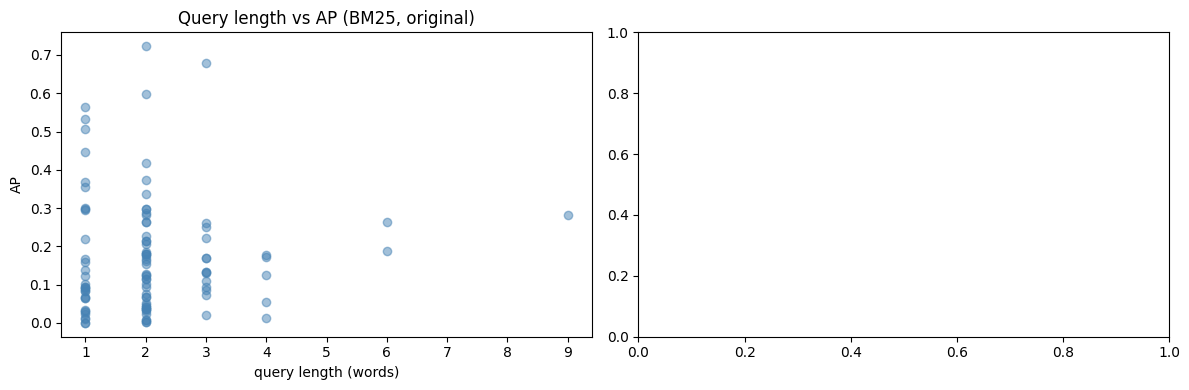

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(pq_bm25['q_len'], pq_bm25['AP'], alpha=0.5, color='steelblue')
ax[0].set_xlabel('query length (words)')
ax[0].set_ylabel('AP')
ax[0].set_title('Query length vs AP (BM25, original)')
plt.tight_layout()
plt.show()

### Morphological processing impact

In [31]:
results[['MAP', 'nDCG@20']].unstack('variant').round(4)

MAP                     nDCG@20                 
variant lemmatized original stemmed lemmatized original stemmed
model                                                          
bm25        0.1719   0.1701  0.1690     0.3594   0.3570  0.3540
tfidf       0.1589   0.1605  0.1543     0.3441   0.3499  0.3354

### Cмотрим на наиболее сложыне вопросы

In [73]:
pd.set_option('display.max_colwidth', None)

hardest_qids = pq_bm25.index[:5]

for qid in hardest_qids:
    query_text = test_queries[qid]
    score = pq_bm25.loc[qid, 'nDCG@20']
    print(f"{'='*70}")
    print(f"query: {query_text}\n")
    display(false_positives(qid, runs['bm25_original']))

pd.reset_option('display.max_colwidth')

query: television presenter



,docid,score,doc_preview
0,424913,16.3004,it made its first broadcast on 19 july 1955 eesti televisioon estonian television was launched on 19 july 1955 before that television broadcasts in estonia could only be received from moscow the very first estonian language tv presenter was ofelia mikk whose debut was in the 19 july 1955 test broadcast alas her tenure in television was cut short because she misspoke out of nervousness the first tenured presenter for the nascent etv was ruth peramets p ss 1927 2005 to find a presenter a casting competition was held in 1955 but no suitable person was found by chance a film in which she starred was aired on etv on the day of the competition and so she was hired kalmer tennosaar began as a presenter on 1 january 1956 and subsequently worked as an editor and fellow of music programmes 1957 1962 and then after 1968 he became very popular as the host of a children s songs show entel tentel tennosaar later continued his career as a singer on 1 january 1993 etv was admitted as a full active member of the european broadcasting union ebu until 31 december 1992 it was a member of the international radio
1,1026929,16.2212,during her career she has covered the business and financial market impact from major news events like the asian economic crisis the dot com bubble crash 9 11 attacks in the us and sars outbreak she received the best news program award at the 2004 asian television awards on behalf of the asian wall street journal the same program also won a finalist award at the 2004 new york festivals for coverage of a breaking news story christine tan also received silver world medal for best anchor at the 2009 new york festivals television programming and promotion awards she also won for best current affairs presenter award at the 2008 asian television awards she was a finalist for best news anchor in 2001 and 2002 at the new york festivals awards and also a best current affairs presenter finalist at the 1997 and 2006 asian television awards tan was also a finalist for best news anchor in 2001 and 2002 at the new york festivals awards she was also a best current affairs presenter finalist at the 1997 asian television awards and received high commendations tan holds a bachelor of arts degree in sociology and english and a master of
2,1035337,16.1599,he is currently the weekend news presenter on nine news queensland uptin has worked across australia on a number of different platforms after completing a communications degree at the university of canberra uptin began his media career at channel nine in sydney as an assistant to the chief of staff before working as a news reporter with prime television and radio station 2gz uptin then joined the nine network at the time channel 8 as a sports reporter before becoming a sports presenter at nbn television in newcastle in 2000 he returned to darwin and was appointed weeknight presenter of eight national news and continued in this role during the conversion to nine news in september 2017 nine news darwin ceased production from the local darwin studios and uptin moved to brisbane where was appointed the co presenter of twelve regional queensland and darwin bulletins with samantha heathwood he remained in this position until february 2018 when a network reshuffle saw him move to presenting the weekend news on the metropolitan nine news queensland bulletin as well as occasionally filling in for wally lewis on the sports segment he had previously occasionally filled in as weekend presenter on the bulletin
3,1827696,15.7029,she was born in moscow russia sadretdinova studied at the russian academy of theatre arts the moscow institute of open education and the training institute of television and radio sadretdinova was presenter of the television program islam on the satellite channel ast from 1999 to 2001 in 2002 she became the tv presenter of the television program muslims on the information and entertainment channels in march 2008 sadretdinova was the guest

query: centrism



,docid,score,doc_preview
0,426292,11.0578,one example is the romanticization of the noble savage in the 18th century primitivism movement in european art philosophy and ethnography xenocentrism is countered by ethnocentrism the perceived superiority of one s own society to others both xenocentrism and ethnocentrism are a subjective take on cultural relativism xenocentrism was coined by american sociologists donald p kent and robert g burnight in the 1952 paper group centrism in complex societies published in the american journal of sociology kent and burnight state that feelings of xenocentrism are caused by three possible factors individuals who have familial ties to a foreign country specifically 2nd or 3rd generation immigrants those who oppose the political choices of their native country an example of this being the communist party usa which idealized the soviet union and its anti capitalist government and individuals who are exposed to other cultures and grow disenchanted with and rebel against their own society the term remained obscure but considered useful and occasionally used by other sociologists the university of florida treats it as a key term of sociology the term is opposed to ethnocentrism as coined by 19th century american sociologist william graham sumner which describes the natural tendencies of an
1,1112200,11.0578,those to have a number one single are shown in bold released in 1970 live at leeds is the most famous live album performed by the who the album was recorded from a concert held at the university of leeds as part of a two leg gig the preferred recording was from the second night at hull however the bass line failed to record so the leeds recording was used instead it is thought by many to be the best live rock album of all time and is included in the book 1001 albums you must hear before you die the album made it to no 3 in the uk charts and no 4 in the us charts live at leeds is a john martyn album he independently released this album himself in an initial run of 10 000 recorded 13 february 1975 the sleeve incorrectly states october at leeds university this is an essential snapshot of martyn at what is possibly his peak the housemartins debut album london 0 hull 4 released in 1986 refers to the band s home town in the form of a sports result the title may have been a jibe at london centrism and
2,141491,11.0578,it is a moderate softly propertarian strain of left libertarian thought often associated with radical centrism geolibertarians maintain that geographical space and raw natural resources any assets that qualify as land by economic definition are rivalrous goods to be considered common property or more accurately unowned which all individuals share an equal human right to access not capital wealth to be privatized fully and absolutely therefore landholders ought to pay compensation according to the rental value set by the free market absent any improvements to the community for the civil right of usufruct that is legally recognized exclusive possession with restrictions on property abuse or otherwise fee simple title with no such restrictions ideally the taxing of a site would be administered only after it has been determined that the privately captured economic rent from the land exceeds the title holder s equal share of total land value in the jurisdiction on this proposal rent is collected not for the mere occupancy or use of land as neither the community nor the state rightfully owns the commons but rather as an objectively assessed indemnity due for the legal right to exclude others from that land some geolibertarians also support pigovian
3,2199815,11.0578,this period is known as the years of centrism gli anni del centrismo the founder of this coalition was alcide de gasperi christian democratic leader and prime minister of italy another key figures of the centrist coalition was the liberal luigi einaudi who was elected president of italy in 1948 and remained in office until 1955 the 

query: elijah wood



,docid,score,doc_preview
0,2179154,16.9676,the series revolves around two half brothers wirt voiced by elijah wood the awkward and pessimistic older brother and gregory voiced by collin dean the energetic and optimistic younger brother the duo travel through a strange forest searching for the way back to their home and encountering wondrous things along their journey on their quest wirt and greg interact with characters such as a bluebird named beatrice voiced by melanie lynskey the woodsman voiced by christopher lloyd and the beast voiced by samuel ramey wirt voiced by elijah wood is the older half brother of gregory he often holds a determined and serious perspective on situations he wears a red pointed hat made from a santa hat a navy blue nurses cape with yellow buttons a pair of grey pants a white shirt and thin suspenders he wears shoes with mismatched colors with one shoe being black and the other being brown his clothes are revealed to be a halloween costume he is an easily frightened pessimist and can become quickly annoyed with greg despite deeply caring for him he has a crush on a girl named sara and often writes and recites poetry he can also play the clarinet
1,444531,16.9676,it was directed by lexi alexander and stars elijah wood and charlie hunnam in the film an american college student falls in with a violent west ham football firm the green street elite run by his brother in law s younger brother and is morally transformed by their commitment to each other two sequels followed in the form of direct to video releases the first was released on various dates around the world between march 2009 to july 2010 the second was released in the uk on 21 october 2013 journalism major matt buckner elijah wood is expelled from harvard university after cocaine is discovered in his room though it belongs to his roommate matt is afraid to speak up because his roommate jeremy comes from a wealthy and powerful family and is offered 10 000 for taking the blame matt accepts the money and uses it to visit his sister shannon claire forlani her husband steve marc warren and their young son ben in london there matt meets steve s brother pete charlie hunnam a teacher and football coach who leads the local football hooligan firm green street elite gse steve asks pete to take matt to a football
2,1203043,15.0749,built about 1769 and subsequently altered it exhibits the progressive adaptation of early houses by later generations it was built by elijah hooker a seventh generation descendant of hartford founder thomas hooker it was listed on the national register of historic places in 1978 the henry hooker house is located on the east side of high road opposite its junction with simms road it is a story wood frame structure five bays wide with two narrow interior chimneys it is covered by a gabled roof with broad eaves that have paired italianate brackets and a gabled dormer at the center of the front facade the front entrance is sheltered by a gabled portico the house was built c 1769 by elijah hooker a seventh generation descendant of hartford founder thomas hooker and was last substantially modernized in the mid 19th century these modifications are clearly evident in an architectural analysis and include the removal of a large central chimney so that a then fashionable central hall with broad stairway could be built these modifications were undertaken by henry hooker who owned a successful carriage making business henry hooker was the son of saxa and clarissa stocking hooker and was born
3,1720124,14.4023,the family included ten sons and five daughters of these steven 1784 1790 charlotte died in 1795 and dexter 1801 1803 died as children sons michael fletcher 1785 1859 calvin fletcher 1798 1866 and stoughton alonzo fletcher 1803 1882 all eventually moved to indiana to seek their fortunes which became intertwined with those of their middle brother elijah daughter lucy fletcher william married a doctor and moved to newark new york whither 

query: pomacentridae



,docid,score,doc_preview
0,1895979,0.0,midflorida has 49 locations throughout the state of florida 318 457 members and 3 49 billion in assets as of march 31st 2019 making midflorida the fourth largest credit union in the state of florida midflorida credit union is regulated by the national credit union administration ncua as a federally insured state chartered credit union midflorida was officially chartered in 1935 and was assigned ncua charter number 68600 midflorida credit union was founded in 1954 in lakeland as the polk county teachers credit union and currently serves a large part of the central florida area in 2002 midflorida expanded its community charter to include okeechobee sumter and hardee counties midflorida became a state chartered credit union in 2009 shortening the company name to midflorida credit union on june 15 2010 midflorida and bay gulf credit union announced a merger between the two credit unions which added bay gulf s approximately 20 000 members and 140 million assets to midflorida then 130 000 members and 1 4 billion assets as a result of the merger midflorida gained access to the tampa bay area and expanded services to all or part of 14 florida counties near the end of 2011 midflorida credit
1,21096,0.0,for work in this field he along with marie sk odowska curie marie curie and pierre curie received the 1903 nobel prize in physics the si unit for radioactivity the becquerel bq is named after him becquerel was born in paris into a wealthy family which produced four generations of physicists becquerel s grandfather antoine c sar becquerel father alexandre edmond becquerel and son jean becquerel henri started off his education by attending the lyc e louis le grand school a prep school in paris he studied engineering at the cole polytechnique and the cole des ponts et chauss es in 1874 henri married lucie zo marie jamin who would die while giving birth to their son jean in 1890 he married louise d sir e lorieux in becquerel s early career he became the third in his family to occupy the physics chair at the mus um national d histoire naturelle in 1892 later on in 1894 becquerel became chief engineer in the department of bridges and highways before he started with his early experiments becquerel s earliest works centered on the subject of his doctoral thesis the plane polarization of light with the phenomenon of phosphorescence and absorption
2,1339722,0.0,xmos microcontrollers are distinguished by their deterministic predictable behavior xmos was founded in july 2005 by ali dixon then final year student at the university of bristol james foster former ceo of oxford semiconductor noel hurley david may former chief architect of inmos and hitesh mehta acacia capital partners it received seed funding from the university of bristol enterprise fund and wyvern seed fund formerly the sulis seedcorn fund the name xmos is a loose reference to inmos some concepts found in xmos technology such as channels and threads are part of the transputer legacy in the autumn of 2006 xmos secured funding from amadeus capital partners dfj esprit and foundation capital it also has strategic investors robert bosch venture capital gmbh huawei technologies and xilinx inc in september 2017 xmos secured 15m in an investment round lead by infineon xmos s processor technology is general purpose and has been exploited in a range of different markets including voice microphone arrays audio led tiles communications and robotics this enables third parties to establish products and businesses based around the technology in december 2009 xmos launched a community website the xcore exchange as a site to enable and encourage innovative and
3,804977,0.0,siva prasad reddy on kamakshi movies banner and directed by v n aditya starring nagarjuna akkineni nayantara poonam bajwa shriya saran in the lead roles and music composed by kalyani malik and harry anand cinematography for the movie was handled by siva kumar while editing was being handled by m

query: homer



,docid,score,doc_preview
0,714086,14.3919,the district serves homer city and center township the district campus is located just south of the homer city center township border along south main street and adjacent to u s route 119 homer center s high school principal is jody rainey homer center s elementary schools principal s michael stofa the district operates two school buildings with a total enrollment of 964 students grades k 12 the district s high school building currently accommodates 491 students while the elementary has an enrollment of 473 students homer center s athletic teams known as the wildcats compete in the heritage conference which resides in the piaa district vi the district does not offer athletics programs at the elementary level however students can participate in programs offered by the homer city area athletic booster club hcaabc hcaabc sponsored teams are nicknamed the homer city bears the homer center school district is ranked 146th out of 576 public school districts in pennsylvania it is also ranked first out of seven public school districts in indiana county the homer center elementary school serves grades k 6 it is located on wildcat lane just north of the high school building the elementary building also contains
1,369820,14.3919,it originally aired on the fox network in the united states on october 24 1999 in the episode homer becomes a food critic for a springfield newspaper and ends up annoying the restaurant owners of springfield after he makes negative reviews just to be mean advice he took from fellow critics springfield s restaurant owners then attempt to kill homer by feeding him a poisoned clair american actor ed asner guest starred in the episode as the newspaper editor that hires homer the episode has received generally mixed reviews from television critics since airing springfield elementary arranges a trip to the offices of the springfield shopper for the students homer volunteers to chaperone the children on the trip first taking them to the zoo they are introduced to the newspaper s history and operations homer smells cake and follows it to a retirement party for the newspaper s food critic crashing the party homer greedily eats the food the editor seeing homer s love of food offers him a job as the new food critic he asks homer to prepare a 500 word sample review first homer struggles with the review but he soon gets help from lisa who helps
2,365071,14.1376,it originally aired on the fox network in the united states on december 20 1998 after homer prevents mayor quimby and mark hamill from being trampled at a convention homer trains to become a bodyguard and is employed by quimby after homer discovers quimby has been making corrupt deals with fat tony and forces him to end the deal fat tony threatens to kill quimby leaving homer to defend the mayor from threats the episode was written by ron hauge and directed by swinton o scott iii and received positive reviews from critics overall while watching television the simpson family sees a commercial for the bi mon sci fi con a science fiction convention featuring mark hamill and others and decide to attend a riot breaks out at the convention after hamill offers the chance for someone in the crowd to act out a scene with him homer notices that mark hamill and mayor quimby are in danger of being trampled due to the riot and quickly rescues them in gratitude quimby employs homer as his bodyguard homer begins training at leavelle s bodyguard academy where he quickly graduates and begins his new job unbeknownst to homer quimby made a
3,1870178,14.1376,it first aired on the fox network in the united states on march 10 2013 the name is a pun on black eyed peas and the band the black eyed peas the couch segment of this episode s intro was animated by bill plympton in a film noir style he also animated one for 2012 and one for 2014 homer invites himself to ned flanders s house for breakfast and finds ned s beatnik parents there ned begins to fee

---

## Task 5.


### Load validation queries and qrels

In [36]:
val_queries = load_queries(SPLITS['validation']['queries'])
val_qrels = load_qrels(SPLITS['validation']['qrels'])
val_query_tok = {qid: preprocess(val_queries[qid], 'lemmatized') for qid in val_queries}

### Grid search over (k1, b)

In [42]:
# K1_GRID = [0.3, 0.4, 0.5]
# B_GRID = [0.0, 0.05, 0.1, 0.15, 0.20, 0.25]

K1_GRID = [0.4, 1.0, 2.0, 5.0]
B_GRID = [0.0, 0.25, 0.5]

tuning_bm25 = BM25Okapi(corpus_tok['lemmatized'])


def eval_bm25_params(model, queries_tok, qrels, k1, b, k=TOP_K):
    model.k1 = k1
    model.b = b
    ranking = {}
    for qid, qtoks in tqdm(queries_tok.items()):
        scores = model.get_scores(qtoks)
        idx = top_k_indices(scores, k)
        ranking[qid] = {doc_ids[i]: float(scores[i]) for i in idx}
    return ir_measures.calc_aggregate([AP, nDCG@20], qrels, ranking)


grid_rows = []
for k1 in tqdm(K1_GRID, desc='поиск по сетке'):
    for b in B_GRID:
        sc = eval_bm25_params(tuning_bm25, val_query_tok, val_qrels, k1, b)
        grid_rows.append({'k1': k1, 'b': b, 'MAP': sc[AP], 'nDCG@20': sc[nDCG@20]})

grid = pd.DataFrame(grid_rows)
grid.sort_values('MAP', ascending=False).head()

поиск по сетке:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

,k1,b,MAP,nDCG@20
0,0.4,0.00,0.152498,0.322698
1,0.4,0.25,0.152435,0.320499
2,0.4,0.50,0.152390,0.320013
5,1.0,0.50,0.150543,0.317451
4,1.0,0.25,0.150465,0.317542


### Heatmap of validation MAP

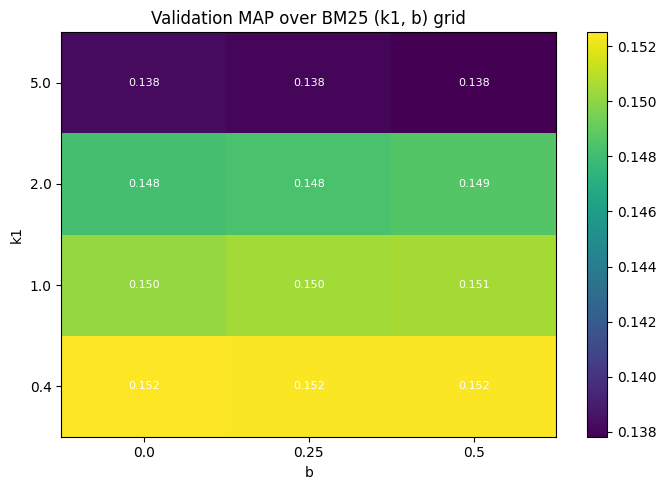

In [43]:
pivot = grid.pivot(index='k1', columns='b', values='MAP')
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap='viridis', aspect='auto', origin='lower')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('b')
ax.set_ylabel('k1')
ax.set_title('Validation MAP over BM25 (k1, b) grid')
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f'{pivot.values[i, j]:.3f}', ha='center', va='center',
                color='white', fontsize=8)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### Делал несколько прогонов Grid search, получилось вот что

In [41]:
best = grid.sort_values('MAP', ascending=False).iloc[0]

best_k1, best_b = float(best['k1']), float(best['b'])

tuning_bm25.k1 = best_k1
tuning_bm25.b = best_b
tuned_ranking = {}
for qid, qtoks in query_tok['lemmatized'].items():
    scores = tuning_bm25.get_scores(qtoks)
    idx = top_k_indices(scores, TOP_K)
    tuned_ranking[qid] = [(doc_ids[i], float(scores[i])) for i in idx]

write_trec_run(tuned_ranking, f'bm25_tuned_k1{best_k1}_b{best_b}', RUNS_DIR / 'bm25_tuned.txt')
tuned_scores = ir_measures.calc_aggregate(MEASURES, test_qrels, to_run_dict(tuned_ranking))

tuned_row = pd.DataFrame([{
    'model': 'bm25',
    'option': f'BEST (k1={best_k1}, b={best_b})',
    'P@1': tuned_scores[P@1],
    'P@10': tuned_scores[P@10],
    'P@20': tuned_scores[P@20],
    'MAP': tuned_scores[AP],
    'nDCG@20': tuned_scores[nDCG@20],
}]).set_index(['model', 'option'])

final = pd.concat([results, tuned_row])
final.round(4)

P@1   P@10    P@20     MAP  nDCG@20
model                                                           
bm25  lemmatized            0.49  0.211  0.1485  0.1719   0.3594
      original              0.49  0.212  0.1500  0.1701   0.3570
      stemmed               0.49  0.209  0.1455  0.1690   0.3540
tfidf lemmatized            0.51  0.201  0.1305  0.1589   0.3441
      original              0.51  0.203  0.1350  0.1605   0.3499
      stemmed               0.50  0.194  0.1285  0.1543   0.3354
bm25  BEST (k1=0.4, b=0.0)  0.49  0.205  0.1430  0.1659   0.3474

### Сравнение с дефолтным bm25

In [44]:
delta = tuned_row.reset_index(drop=True).iloc[0] - results.loc[('bm25', 'original')]
delta.round(4)

P@1        0.0000
P@10      -0.0070
P@20      -0.0070
MAP       -0.0043
nDCG@20   -0.0095
dtype: float64

---

## Additional task 1.MIRAGE Collection. 

In [45]:
from datasets import load_dataset

mirage = load_dataset('nlpai-lab/mirage')
mirage_split = list(mirage.keys())[0]
mirage_example = mirage[mirage_split][0]
print(list(mirage_example.keys()))
mirage[mirage_split].features

'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: dd10a47c-2a4b-46a9-97a0-39672af39ee5)')' thrown while requesting HEAD https://huggingface.co/datasets/nlpai-lab/mirage/resolve/main/README.md
Retrying in 1s [Retry 1/5].


['source', 'query_id', 'query', 'doc_name', 'answer', 'doc_url', 'num_doc_labels', 'doc_pool', 'oracle']


{'source': Value('string'),
 'query_id': Value('string'),
 'query': Value('string'),
 'doc_name': Value('string'),
 'answer': List(Value('string')),
 'doc_url': Value('string'),
 'num_doc_labels': Value('int32'),
 'doc_pool': {'mapped_id': List(Value('string')),
  'doc_name': List(Value('string')),
  'doc_chunk': List(Value('string')),
  'support': List(Value('int32'))},
 'oracle': {'mapped_id': Value('string'),
  'doc_name': Value('string'),
  'doc_chunk': Value('string'),
  'support': Value('int32')}}

In [51]:
def load_mirage(seed=RANDOM_SEED):
    """
      corpus: {doc_id: text}
      queries: {qid: text}
      qrels:  {qid: {doc_id: 1}}  (binary; 'support'==1 marks relevant)
    Corpus = union of doc chunks across all query pools (deduplicated by text hash).
    """
    data = load_dataset("nlpai-lab/mirage", split="train")
    data = data.shuffle(seed=seed).select(range(len(data)))


    corpus, queries, qrels = {}, {}, {}
    text_to_id = {}

    def doc_id_for(text, hint):
        if text in text_to_id:
            return text_to_id[text]
        did = f"d{len(text_to_id)}_{hint[:40].replace(' ', '_')}"
        text_to_id[text] = did
        corpus[did] = text
        return did

    for row in data:
        qid = row["query_id"]
        queries[qid] = row["query"]
        qrels[qid] = {}

        pool = row["doc_pool"]
        names = pool["doc_name"]
        chunks = pool["doc_chunk"]
        supports = pool.get("support", [0] * len(chunks))

        for name, chunk, sup in zip(names, chunks, supports):
            did = doc_id_for(chunk, name)
            if int(sup) > 0:
                qrels[qid][did] = 1
                
    print(f"MIRAGE. Всего queries: {len(queries)}, размер корпуса документов: {len(corpus)}")
    return corpus, queries, qrels

mirage_corpus, mirage_queries, mirage_qrels = load_mirage()

'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: d00b9913-20b4-491b-9c37-e9b835bd94ae)')' thrown while requesting HEAD https://huggingface.co/datasets/nlpai-lab/mirage/resolve/main/README.md
Retrying in 1s [Retry 1/5].


MIRAGE. Всего queries: 7560, размер корпуса документов: 36864


### Parse passages and build qrels

In [52]:
def evaluate_collection(corpus_map, queries_map, qrels_map, k=TOP_K):
    cids = list(corpus_map)
    ctoks = [tokenize(corpus_map[c]) for c in tqdm(cids, desc='')]
    vec = TfidfVectorizer(token_pattern=r'\S+', lowercase=False)
    mat = vec.fit_transform(' '.join(t) for t in ctoks)
    bm = BM25Okapi(ctoks)
    out = {}
    for name in ['tfidf', 'bm25']:
        ranking = {}
        for qid, qtext in tqdm(queries_map.items(), desc=''):
            qt = tokenize(qtext)
            if name == 'tfidf':
                sims = cosine_similarity(vec.transform([' '.join(qt)]), mat).ravel()
            else:
                sims = bm.get_scores(qt)
            idx = top_k_indices(sims, k)
            ranking[qid] = {cids[i]: float(sims[i]) for i in idx}
        out[name] = ir_measures.calc_aggregate(MEASURES, qrels_map, ranking)
    return out


def scores_row(agg):
    return {'P@1': agg[P@1], 'P@10': agg[P@10], 'P@20': agg[P@20],
            'MAP': agg[AP], 'nDCG@20': agg[nDCG@20]}

### Apply our pipeline and compare

In [53]:
mirage_scores = evaluate_collection(mirage_corpus, mirage_queries, mirage_qrels)

wikir_tfidf = dict(zip(['P@1', 'P@10', 'P@20', 'MAP', 'nDCG@20'],
                       results.loc[('tfidf', 'original')].values))
wikir_bm25 = dict(zip(['P@1', 'P@10', 'P@20', 'MAP', 'nDCG@20'],
                      results.loc[('bm25', 'original')].values))

comparison = pd.DataFrame([
    {'collection': 'wikIR1k', 'model': 'tfidf', **wikir_tfidf},
    {'collection': 'wikIR1k', 'model': 'bm25', **wikir_bm25},
    {'collection': 'MIRAGE', 'model': 'tfidf', **scores_row(mirage_scores['tfidf'])},
    {'collection': 'MIRAGE', 'model': 'bm25', **scores_row(mirage_scores['bm25'])},
]).set_index(['collection', 'model'])
comparison.round(4)

  0%|          | 0/36864 [00:00<?, ?it/s]

  0%|          | 0/7560 [00:00<?, ?it/s]

  0%|          | 0/7560 [00:00<?, ?it/s]

P@1    P@10    P@20     MAP  nDCG@20
collection model                                         
wikIR1k    tfidf  0.5100  0.2030  0.1350  0.1605   0.3499
           bm25   0.4900  0.2120  0.1500  0.1701   0.3570
MIRAGE     tfidf  0.3106  0.0807  0.0449  0.4259   0.5059
           bm25   0.4886  0.0885  0.0473  0.5667   0.6250

---

## Additional task 2. Tolstoy and Dostoevsky

In [54]:
import requests
from urllib.parse import urljoin
from bs4 import BeautifulSoup

HEADERS = {'User-Agent': 'Mozilla/5.0 (compatible; educational-research)'}

def fetch_azlib(author_url, keywords):
    resp = requests.get(author_url, headers=HEADERS, timeout=30)
    resp.encoding = 'cp1251'
    soup = BeautifulSoup(resp.text, 'html.parser')
    for a in soup.find_all('a', href=True):
        anchor = a.get_text(strip=True).lower()
        if any(kw in anchor for kw in keywords):
            href = urljoin(author_url, a['href'])
            page = requests.get(href, headers=HEADERS, timeout=180)
            page.encoding = 'cp1251'
            body = BeautifulSoup(page.text, 'html.parser')
            return body.get_text(separator=' ')
    raise ValueError(f'no link matching {keywords!r} on {author_url}')


TOLSTOY_URL = 'http://az.lib.ru/t/tolstoj_lew_nikolaewich/'
DOSTOEVSKY_URL = 'http://az.lib.ru/d/dostoewskij_f_m/'

raw_tolstoy = fetch_azlib(TOLSTOY_URL, ['война и мир'])
time.sleep(2)
raw_dostoevsky = fetch_azlib(DOSTOEVSKY_URL, ['братья карамазов'])

### Разбиение по абзацам

In [55]:
RU_TOKEN_RE = re.compile(r'[а-яёa-z]+')


def split_paragraphs(text, min_words=40):
    paras = []
    for chunk in re.split(r'\n\s*\n|\s{4,}', text):
        words = RU_TOKEN_RE.findall(chunk.lower())
        if len(words) >= min_words:
            paras.append(words)
    return paras


paras_tolstoy = split_paragraphs(raw_tolstoy)
paras_dostoevsky = split_paragraphs(raw_dostoevsky)
all_paras = paras_tolstoy + paras_dostoevsky
pd.Series({
    'tolstoy paragraphs': len(paras_tolstoy),
    'dostoevsky paragraphs': len(paras_dostoevsky),
}, name='count')

tolstoy paragraphs       816
dostoevsky paragraphs    326
Name: count, dtype: int64

### Pairwise similarity under two IDF regimes

In [65]:
def preview(paragraph, PREVIEW):
    return ' '.join(paragraph[:PREVIEW])

def fit_tfidf(idf_corpus):
    vec = TfidfVectorizer(token_pattern=r'\S+', lowercase=False)
    vec.fit(' '.join(p) for p in idf_corpus)
    return vec


def within_sim(paras, vec):
    mat = vec.transform(' '.join(p) for p in paras)
    sims = cosine_similarity(mat)
    np.fill_diagonal(sims, -1)
    i, j = np.unravel_index(sims.argmax(), sims.shape)
    if i > j:
        i, j = j, i
    return int(i), int(j), sims[i, j]


def top_cross_pair(paras_a, paras_b, vec):
    a = vec.transform(' '.join(p) for p in paras_a)
    b = vec.transform(' '.join(p) for p in paras_b)
    sims = cosine_similarity(a, b)
    i, j = np.unravel_index(sims.argmax(), sims.shape)
    return int(i), int(j), sims[i, j]

In [70]:
PREVIEW=40

vec_tol = fit_tfidf(paras_tolstoy)
vec_dos = fit_tfidf(paras_dostoevsky)
vec_all = fit_tfidf(all_paras)

cases = [
    ('Толстой - внутри',       *within_sim(paras_tolstoy,   vec_all), paras_tolstoy,   paras_tolstoy),
    ('Достоевский - внутри',   *within_sim(paras_dostoevsky, vec_all), paras_dostoevsky, paras_dostoevsky),
    ('Толстой vs Достоевский', *top_cross_pair(paras_tolstoy, paras_dostoevsky, vec_all), paras_tolstoy, paras_dostoevsky),
]

for label, i, j, sim, src_a, src_b in cases:
    print('{=================}')
    print(f'{label}  (cosine = {sim:.4f})')
    print(f'  [paragraph {i}] {preview(src_a[i], 300)}')
    print(f'  [paragraph {j}] {preview(src_b[j], 300)}\n')

{=================}
Толстой - внутри  (cosine = 0.6547)
  [paragraph 236] tout moscou ne parle que guerre l un de mes deux fr res est d j l tranger l autre est avec la garde qui se met en marche vers la fronti re notre cher empereur a quitt p tersbourg et ce qu on pr tend compte lui m me exposer sa pr cieuse existence aux chances de la guerre dieu veuille que le monstre corsicain qui d truit le repos de l europe soit terrass par l ange que le tout puissant dans sa mis ricorde nous a donn pour souverain sans parler de mes fr res cette guerre m a priv e d une relation des plus ch res mon coeur je parle du jeune nicolas rostoff qui avec son enthousiasme n a pu supporter l inaction et a quitt l universit pour aller s enr ler dans l arm e eh bien ch re marie je vous avouerai que malgr son extr me jeunesse son d part pour l arm e a t un grand chagrin pour moi le jeune homme dont je vous parlais cet t a tant de noblesse de v ritable jeunesse qu on rencontre si rarement dans le si cle ou nous 